# Softmax Regression (Generalization of Logistic Regression)

### Loading data

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df = sns.load_dataset('iris')

In [4]:
df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
95,5.7,3.0,4.2,1.2,versicolor
46,5.1,3.8,1.6,0.2,setosa
44,5.1,3.8,1.9,0.4,setosa
51,6.4,3.2,4.5,1.5,versicolor
93,5.0,2.3,3.3,1.0,versicolor


### Encoding Output column, and splitting data

In [5]:
from sklearn.preprocessing import LabelEncoder

In [6]:
encoder = LabelEncoder()

In [7]:
df['species'] = encoder.fit_transform(df['species'])

In [9]:
df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
60,5.0,2.0,3.5,1.0,1
49,5.0,3.3,1.4,0.2,0
146,6.3,2.5,5.0,1.9,2
98,5.1,2.5,3.0,1.1,1
73,6.1,2.8,4.7,1.2,1


In [14]:
df = df[["sepal_length", "petal_length", "species"]]

In [17]:
df.sample(2)

,sepal_length,petal_length,species
47,4.6,1.4,0
94,5.6,4.2,1


In [18]:
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=18)

### Training the model using the **multinomial features**

In [23]:
from sklearn.linear_model import LogisticRegression

In [25]:
softmax_reg = LogisticRegression(solver='lbfgs')

In [26]:
softmax_reg.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [27]:
y_pred = softmax_reg.predict(x_test)

### Testing our model

In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [29]:
accuracy_score(y_test, y_pred)

0.9666666666666667

In [31]:
pd.DataFrame(confusion_matrix(y_test, y_pred))

,0,1,2
0,12,0,0
1,0,8,0
2,0,1,9


In [32]:
softmax_reg.coef_, softmax_reg.intercept_

(array([[-0.25976604, -2.9053586 ],
        [ 0.40686928, -0.35323631],
        [-0.14710325,  3.25859491]]),
 array([ 11.6685619 ,   1.27067588, -12.93923778]))

### Prediction on new data

In [36]:
np.set_printoptions(precision=4, suppress=True)  # prevents to give result in scientific notation (__ e -0.12)

In [35]:
query = np.array([[3.4, 2.7]])
softmax_reg.predict_proba(query)

E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.7754, 0.2242, 0.0004]])

In [37]:
softmax_reg.predict(query)

E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

### Visualizing the determination of the model

In [39]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

E:\Anaconda\Anaconda2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


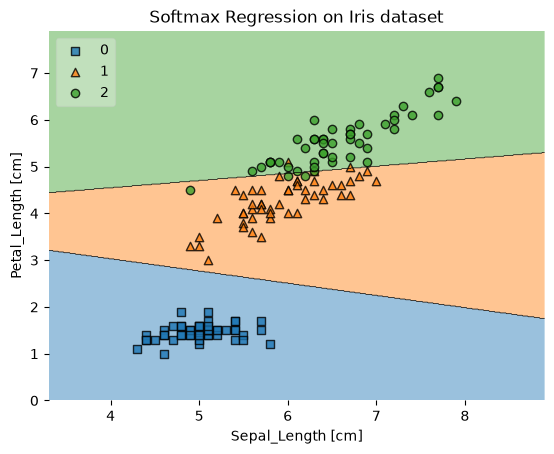

In [41]:
plot_decision_regions(x.values, y.values, softmax_reg, legend=2)

plt.title("Softmax Regression on Iris dataset")
plt.xlabel("Sepal_Length [cm]")
plt.ylabel("Petal_Length [cm]")
plt.show()